# Preamble

## Imports & Path

In [1]:
%cd ..

/home/aru/Work/shome2023notebook


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, fisher_exact, MonteCarloMethod
from scipy.stats.contingency import association

In [3]:
sns.set_theme(
    context="talk",
    palette="colorblind",
    style="whitegrid",
)

## Data Loading & Prep


In [4]:
data = pd.read_csv("data/shome2023notebook/annotations.csv")
data

,notebook,stmt,source,CALL,CGH,CKG,EC,Intent,Stage,Notes,Type
0,data/assert_notebooks/lepmik/meta-reinforcemen...,np.unique(env._s_hist[:-1][np.diff(env._s_hist...,GH,-1,-2.0,NaN,NaN,EXP,EVAL,RL context. Diagnostic to identify which state...,COMPUTE
1,data/assert_notebooks/dhuynh95/cryptotree/nbs/...,"(comparator.weight.data, comparator.bias.data)",GH,117,-2.0,NaN,NaN,EXP,EVAL,Check learned weights and bias of model.,INSPECT
2,data/assert_notebooks/nikohou/LoadLanguageMode...,assert dim % 2 == 0,GH,992,-2.0,NaN,NaN,VAL,MODEL,Defined inside `__init__` method of a neural n...,EQ
3,data/assert_notebooks/EricCousineau-TRI/repro/...,assert activated.ndim > 1,GH,1021,-2.0,NaN,NaN,VAL,MODEL,"Ensure activation tensor is a batch (2D), not ...",SHAPE
4,data/assert_notebooks/H-E-L-P/XID_plus/docs/bu...,"plt.plot(test_x, test_y, 'ro', alpha=0.5)",GH,614,-2.0,NaN,NaN,EXP,EVAL,Visually inspect actual vs. predictions of the...,INSPECT
...,...,...,...,...,...,...,...,...,...,...,...
810,data/quaranta2021kgtorrent/KT_dataset/jackchun...,assert skip_end >= 0,KG,1056,NaN,229.0,NaN,VAL,TRAIN,Defined inside method to find learning rate fo...,BOOL
811,data/quaranta2021kgtorrent/KT_dataset/dazzpool...,max(accuracy),KG,735,NaN,353.0,NaN,EXP,EVAL,NaN,COMPUTE
812,data/quaranta2021kgtorrent/KT_dataset/amit1201...,plt.plot(indexed_dataset_logScale),KG,632,NaN,470.0,NaN,EXP,PREP,Visually inspect log transform series to inspe...,INSPECT
813,data/quaranta2021kgtorrent/KT_dataset/imprime_...,test_df.isnull().sum().head(60),KG,560,NaN,589.0,NaN,EXP,PREP,NaN,COMPUTE


## Helper Functions

In [5]:
def annot_count_with_percent(ax, orient="v") -> None:
    """Annotate each bar with count and percentage relative to hue size."""
    get_val = (lambda p: p.get_width()) if orient == "h" else (lambda p: p.get_height())
    for container in ax.containers:
        total = sum(get_val(p) for p in container)
        labels = [
            f"{int(get_val(p))} ({100 * get_val(p) / total:.1f}%)"
            for p in container
        ]
        ax.bar_label(container, labels=labels, fontsize=10.0)

In [6]:
def annot_histplot_with_percent(ax, rotation=0) -> None:
    """Annotate each bar in a stacked histplot with percentage."""
    for patch in ax.patches:
        width = patch.get_width()
        if width < 0.04:          # skip slivers to avoid overlap
            continue
        x = patch.get_x() + width / 2
        y = patch.get_y() + patch.get_height() / 2
        ax.text(x, y, f'{width:.1%}', ha='center', va='center',
                color='white', fontsize=10, rotation=rotation)

In [7]:
def counts(row, col):
    freq = pd.crosstab(row, col)
    pct = pd.crosstab(row, col, normalize="index")
    return freq, pct

In [8]:
def pearson_residuals(observed, expected):
    """Calculate the Pearson residuals from expected frequencies."""
    residuals = (observed - expected) / np.sqrt(expected)

    return residuals

In [9]:
def chi2(observed_freq):
    statistic, pvalue, dof, expected_freq = chi2_contingency(observed_freq)

    if dof == 1:
        if (expected_freq < 5).any():
            print("WARNING: Some expected frequencies are less than 5. Chi-square approximation may be invalid.")
    else:
        total = expected_freq.size
        pct_less_than_5 = (expected_freq < 5).sum() / total
        if pct_less_than_5 > 0.20 or (expected_freq < 1).any():
            print("WARNING: More than 20% of expected frequencies are less than 5, or at least one is less than 1. Chi-square approximation may be invalid.")

    cramers_v = association(observed_freq, method="cramer", correction=True)
    residuals = pearson_residuals(observed_freq, expected_freq)

    print(f"statistic: {statistic}")
    print(f"pvalue: {pvalue}")
    print(f"dof: {dof}")
    print(f"cramer's v: {cramers_v}")
    print(f"expected_freq:\n{expected_freq}")
    print(f"residuals:\n{residuals}")

In [10]:
def fisher(observed_freq):
    rng = np.random.default_rng()
    method = MonteCarloMethod(rng=rng)
    statistic, pvalue = fisher_exact(observed_freq, method=method)
    cramers_v = association(observed_freq, method="cramer", correction=True)
    
    print(f"statistic: {statistic}")
    print(f"pvalue: {pvalue}")
    print(f"cramer's v: {cramers_v}")

# RQ1: Prevalence and Variation of Feedback Mechanisms

In [11]:
TOTAL = len(data)
gh = data[data["source"] == "GH"]
kg = data[data["source"] == "KG"]

print(f"Total number of notebooks: {len(data["notebook"].unique())}")
print(f"Total number of statements: {len(data["stmt"].unique())}")
print(
    f"GH stmts: {len(gh)} ({len(gh) / TOTAL * 100:.0f}%),\
    KG stmts: {len(kg)} ({len(kg) / TOTAL * 100:.0f}%)"
)

Total number of notebooks: 792
Total number of statements: 815
GH stmts: 382 (47%),    KG stmts: 433 (53%)


## Intent x Source

In [12]:
freq, pct = counts(data["source"], data["Intent"])

In [13]:
freq

Intent,EXP,VAL
source,,
GH,263,119
KG,429,4


In [14]:
pct

Intent,EXP,VAL
source,,
GH,0.688482,0.311518
KG,0.990762,0.009238


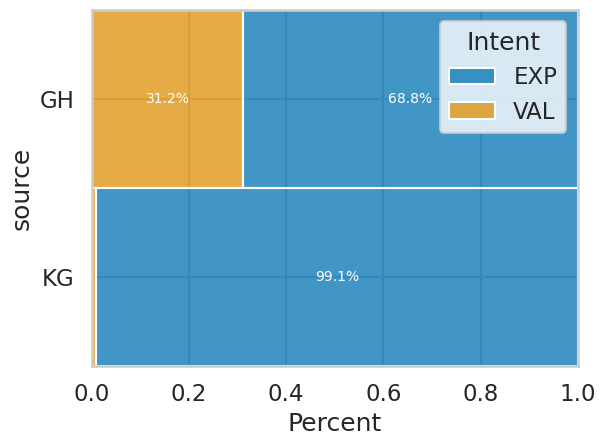

In [15]:
ax = sns.histplot(
    data=data,
    y='source',
    hue='Intent',
    stat='percent',
    multiple='fill',
)
annot_histplot_with_percent(ax)
ax.get_figure().tight_layout()
ax.get_figure().savefig("report/distribution-intent.pdf")

Are the two populations siginificantly different from one another?

In [16]:
chi2(freq)

statistic: 142.36709812111934
pvalue: 8.083770205966849e-33
dof: 1
cramer's v: 0.41795161918197365
expected_freq:
[[324.34846626  57.65153374]
 [367.65153374  65.34846626]]
residuals:
Intent       EXP       VAL
source                    
GH     -3.406417  8.079757
KG      3.199525 -7.589025


$pvalue < 0.001$ so we reject $H_0$. This means that there is a significant difference between the Intent of the statements from GH and KG.

## Type-EXP x Source

In [17]:
d = data[data["Intent"] == "EXP"]

In [18]:
freq, pct = counts(d["source"], d["Type"])
freq

Type,COMPUTE,INSPECT,STATS,STRUCT
source,,,,
GH,82,121,20,40
KG,103,182,58,86


In [19]:
pct

Type,COMPUTE,INSPECT,STATS,STRUCT
source,,,,
GH,0.311787,0.460076,0.076046,0.152091
KG,0.240093,0.424242,0.135198,0.200466


Are the populations significantly different? We apply $X^2$ test since the sample size is large.

In [20]:
chi2(freq)

statistic: 10.769711813259374
pvalue: 0.013038590514346938
dof: 3
cramer's v: 0.12475242426582903
expected_freq:
[[ 70.31069364 115.15751445  29.64450867  47.88728324]
 [114.68930636 187.84248555  48.35549133  78.11271676]]
residuals:
Type     COMPUTE   INSPECT     STATS    STRUCT
source                                        
GH      1.394049  0.544442 -1.771365 -1.139770
KG     -1.091509 -0.426286  1.386939  0.892414


## Type-VAL x Source

In [21]:
d = data[data["Intent"] == "VAL"]
d.shape

(123, 11)

In [22]:
freq, pct = counts(d["source"], d["Type"])
freq

Type,APPROX,BOOL,EQ,EXIST,SHAPE,TYPE
source,,,,,,
GH,8,18,34,6,47,6
KG,0,3,1,0,0,0


In [23]:
pct

Type,APPROX,BOOL,EQ,EXIST,SHAPE,TYPE
source,,,,,,
GH,0.067227,0.151261,0.285714,0.05042,0.394958,0.05042
KG,0.000000,0.750000,0.250000,0.00000,0.000000,0.00000


Are the populations significantly different? We apply $X^2$ test since the sample size is large.

In [24]:
chi2(freq)

statistic: 10.395198079231692
pvalue: 0.06478127860957235
dof: 5
cramer's v: 0.29071258232523906
expected_freq:
[[ 7.7398374  20.31707317 33.86178862  5.80487805 45.47154472  5.80487805]
 [ 0.2601626   0.68292683  1.13821138  0.19512195  1.52845528  0.19512195]]
residuals:
Type      APPROX      BOOL        EQ     EXIST     SHAPE      TYPE
source                                                            
GH      0.093514 -0.514055  0.023751  0.080986  0.226664  0.080986
KG     -0.510061  2.803836 -0.129548 -0.441726 -1.236307 -0.441726


Note that we do not have enough data for any statistical tests (not even Fisher). Thus for this section we provide a descriptive reporting.

## Type x Source

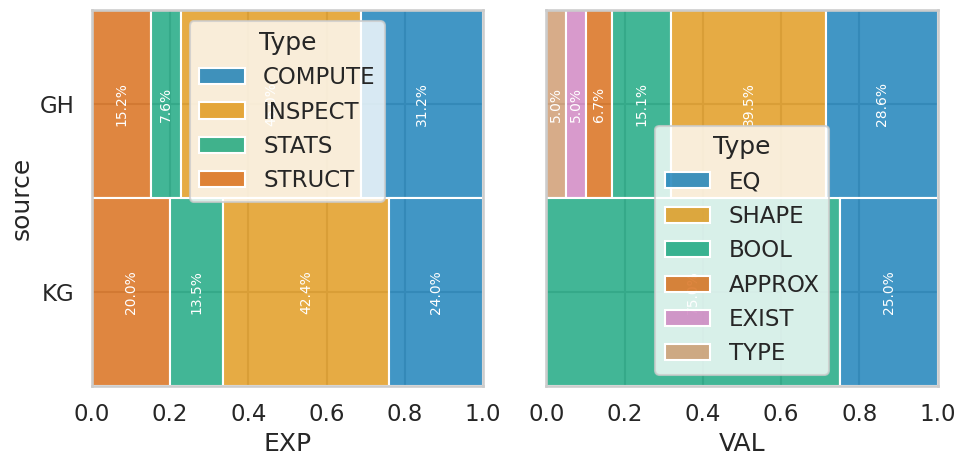

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
sns.histplot(
    data=data[data["Intent"] == "EXP"],
    y='source',
    hue='Type',
    multiple='fill',
    stat='percent',
    ax=ax1,
)
sns.histplot(
    data=data[data["Intent"] == "VAL"],
    y='source',
    hue='Type',
    multiple='fill',
    stat='percent',
    ax=ax2,
)
annot_histplot_with_percent(ax1, rotation=90)
annot_histplot_with_percent(ax2, rotation=90)
ax1.set_xlabel("EXP")
ax2.set_xlabel("VAL")
fig.tight_layout()
fig.savefig("report/distribution-type.pdf")

# RQ2: Pipeline Stage Distribution of Validation Statements

Stage contains two UNC which can be dropped.

In [26]:
data = data[data["Stage"] != "UNC"]
data.shape

(813, 11)

Values in Stage have an order.

In [27]:
STAGE_ORDER = ["DATA", "PREP", "FEAT", "MODEL", "TRAIN", "EVAL"]
data['Stage'] = pd.Categorical(
    data['Stage'],
    categories=STAGE_ORDER,
    ordered=True
)

## Stage x Source

In [28]:
freq, _ = counts(data["source"], data["Stage"])
freq

Stage,DATA,PREP,FEAT,MODEL,TRAIN,EVAL
source,,,,,,
GH,71,76,49,40,50,94
KG,29,253,51,2,21,77


Are the two populations siginificantly different from one another?

In [29]:
chi2(freq)

statistic: 158.0375319815066
pvalue: 2.5927632872693826e-32
dof: 5
cramer's v: 0.4408946679404677
expected_freq:
[[ 46.7404674  153.77613776  46.7404674   19.63099631  33.18573186
   79.92619926]
 [ 53.2595326  175.22386224  53.2595326   22.36900369  37.81426814
   91.07380074]]
residuals:
Stage       DATA      PREP      FEAT     MODEL     TRAIN      EVAL
source                                                            
GH      3.548427 -6.271940  0.330500  4.597255  2.918786  1.574225
KG     -3.324174  5.875567 -0.309614 -4.306718 -2.734325 -1.474737


$pvalue < 0.001$ so we reject $H_0$. This means that there is a significant difference between the Intent of the statements from GH and KG.

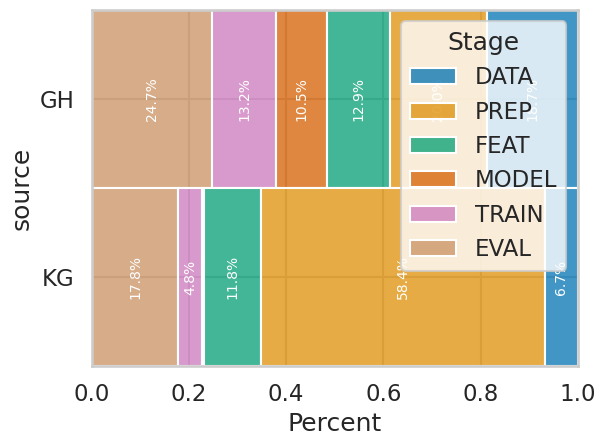

In [30]:
ax = sns.histplot(
    data=data,
    y='source',
    hue='Stage',
    stat='percent',
    multiple='fill',
)
annot_histplot_with_percent(ax, rotation=90)
ax.get_figure().tight_layout()
ax.get_figure().savefig("report/distribution-stage.pdf")

## Intent x Stage
- Stratify the tests by source since source is a confounding variable.

### GH

In [31]:
d = data[(data["source"] == "GH")]
d.shape

(380, 11)

In [32]:
freq, pct = counts(d["Intent"], d["Stage"])
freq

Stage,DATA,PREP,FEAT,MODEL,TRAIN,EVAL
Intent,,,,,,
EXP,54,53,35,16,33,72
VAL,17,23,14,24,17,22


In [33]:
pct

Stage,DATA,PREP,FEAT,MODEL,TRAIN,EVAL
Intent,,,,,,
EXP,0.205323,0.201521,0.133080,0.060837,0.125475,0.273764
VAL,0.145299,0.196581,0.119658,0.205128,0.145299,0.188034


In [34]:
pd.crosstab(d["Intent"], d["Stage"], normalize="columns")

Stage,DATA,PREP,FEAT,MODEL,TRAIN,EVAL
Intent,,,,,,
EXP,0.760563,0.697368,0.714286,0.4,0.66,0.765957
VAL,0.239437,0.302632,0.285714,0.6,0.34,0.234043


Are the two populations siginificantly different from one another?

In [35]:
chi2(freq)

statistic: 20.348620358884357
pvalue: 0.0010747724553696262
dof: 5
cramer's v: 0.2314065706595915
expected_freq:
[[49.13947368 52.6        33.91315789 27.68421053 34.60526316 65.05789474]
 [21.86052632 23.4        15.08684211 12.31578947 15.39473684 28.94210526]]
residuals:
Stage       DATA      PREP      FEAT     MODEL     TRAIN      EVAL
Intent                                                            
EXP     0.693375  0.055153  0.186630 -2.220666 -0.272882  0.860679
VAL    -1.039568 -0.082690 -0.279813  3.329417  0.409129 -1.290405


$pvalue = 0.001$ so we reject $H_0$. The test indicates that intent of statements is associated with the stage.

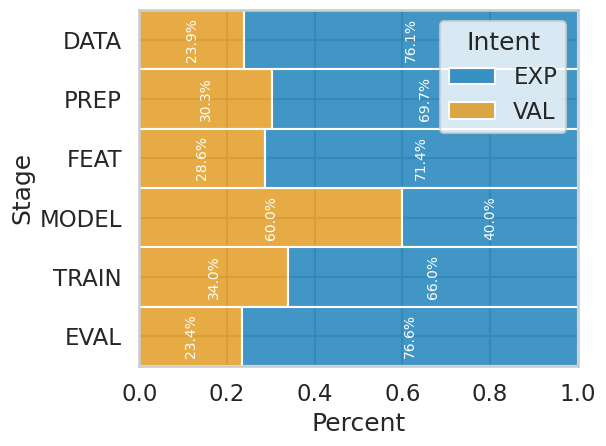

In [46]:
ax = sns.histplot(
    data=d,
    y='Stage',
    hue='Intent',
    multiple='fill',
    stat='percent',
)
annot_histplot_with_percent(ax, rotation=90)
ax.get_figure().tight_layout()
ax.get_figure().savefig("report/distribution-stage-intent.pdf")

### KG

In [37]:
d = data[(data["source"] == "KG")]
d.shape

(433, 11)

In [38]:
freq, pct = counts(d["Intent"], d["Stage"])
freq

Stage,DATA,PREP,FEAT,MODEL,TRAIN,EVAL
Intent,,,,,,
EXP,29,252,51,1,20,76
VAL,0,1,0,1,1,1


In [39]:
pct

Stage,DATA,PREP,FEAT,MODEL,TRAIN,EVAL
Intent,,,,,,
EXP,0.067599,0.587413,0.118881,0.002331,0.04662,0.177156
VAL,0.000000,0.250000,0.000000,0.250000,0.25000,0.250000


In [40]:
pd.crosstab(d["Intent"], d["Stage"], normalize="columns")

Stage,DATA,PREP,FEAT,MODEL,TRAIN,EVAL
Intent,,,,,,
EXP,1.0,0.996047,1.0,0.5,0.952381,0.987013
VAL,0.0,0.003953,0.0,0.5,0.047619,0.012987


Are the two populations siginificantly different from one another?

In [41]:
chi2(freq)

statistic: 57.64599821566225
pvalue: 3.721366488026973e-11
dof: 5
cramer's v: 0.3648720811489848
expected_freq:
[[2.87321016e+01 2.50662818e+02 5.05288684e+01 1.98152425e+00
  2.08060046e+01 7.62886836e+01]
 [2.67898383e-01 2.33718245e+00 4.71131640e-01 1.84757506e-02
  1.93995381e-01 7.11316397e-01]]
residuals:
Stage       DATA      PREP      FEAT     MODEL     TRAIN      EVAL
Intent                                                            
EXP     0.049979  0.084459  0.066278 -0.697271 -0.176703 -0.033052
VAL    -0.517589 -0.874670 -0.686390  7.221044  1.829961  0.342287


Conditions for $\chi^2$ not satisfied, use Fisher instead.

In [42]:
fisher(freq)

statistic: 0.0005664406461858148
pvalue: 0.0093
cramer's v: 0.3648720811489848


$pvalue = 0.001$ so we reject $H_0$ however the effect size is unstable at such low counts. Best course of action is to report descriptively, stratified by source (similar to RQ1).

## Type x Stage

- We restrict this analysis only to GH.
- Interpretation of stage: how far into the lifecycle.
- As we move forward (maturity increase), are the assertion types changing and how?
- How would knowing this help? Why do we care what type of assertion is used in which stage?
- Would we change tools and how notebooks are designed based on this knowledge?
- Are there some types of assertions that are less recommended than others?

In [43]:
d = data[data["source"] == "GH"]
d.shape

(380, 11)

In [44]:
val = d[d["Intent"] == "VAL"]
freq1 = pd.crosstab(val["Stage"], val["Type"])
pct1 = pd.crosstab(val["Stage"], val["Type"], normalize="index")

exp = d[d["Intent"] == "EXP"]
freq2 = pd.crosstab(exp["Stage"], exp["Type"])
pct2 = pd.crosstab(exp["Stage"], exp["Type"], normalize="index")

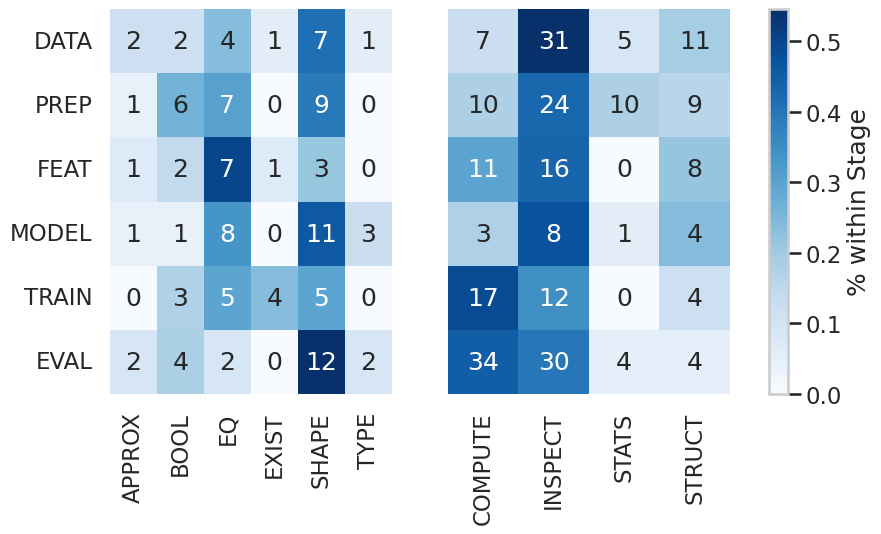

In [48]:
fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(10,5), sharey=True)
sns.heatmap(
    pct1.rename_axis(index=None, columns=None),
    annot=freq1.rename_axis(index=None, columns=None),
    vmin=pct1.min().min(),
    vmax=pct1.max().max(),
    cbar=False,
    fmt="d",
    cmap="Blues",
    # square=True,
    ax=ax1,
)
sns.heatmap(
    pct2.rename_axis(index=None, columns=None),
    annot=freq2.rename_axis(index=None, columns=None),
    vmin=pct2.min().min(),
    vmax=pct2.max().max(),
    cbar=False,
    fmt="d",
    cmap="Blues",
    # square=True,
    ax=ax2,
)
fig.colorbar(
    ax1.collections[0],
    ax=[ax1, ax2],
    label="% within Stage"
)
fig.savefig("report/distribution-stage-type.pdf")